In [1]:
from pathlib import Path
from scipy.io import loadmat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
data_folder = Path("DD_data")
mat_files = sorted(data_folder.glob("*.mat"))

In [3]:
# get colummns of the dataframes
data_0 = loadmat(mat_files[0])
data_labels = data_0["data_labels"]
columns = [label[0] for label in data_labels[0]]

print(columns)

['immOutcome', 'delOutcome', 'delay', 'action (1=immediate, 2=delayed, 0=missing)', 'p_imm', 'condition (1=reward,2=loss)', 'RT']


In [4]:
# convert data to dataframes
participants = []

for file in mat_files:
    data = loadmat(file)

    train_df = pd.DataFrame(data["data_train"], columns=columns)
    test_df = pd.DataFrame(data["data_test"], columns=columns)

    participants.append({
        "train": train_df,
        "test": test_df
    })

In [5]:
participants[0]["train"]

,immOutcome,delOutcome,delay,"action (1=immediate, 2=delayed, 0=missing)",p_imm,"condition (1=reward,2=loss)",RT
0,1.79,5.0,180.0,1.0,0.5,1.0,1721.1
1,9.99,10.0,30.0,1.0,0.5,1.0,2190.2
2,7.33,10.0,365.0,1.0,0.5,1.0,1590.0
3,0.46,50.0,180.0,2.0,0.5,1.0,1804.1
4,0.91,50.0,90.0,2.0,0.5,1.0,1722.5
...,...,...,...,...,...,...,...
75,48.54,50.0,30.0,1.0,0.5,1.0,3756.2
76,4.59,5.0,90.0,1.0,0.5,1.0,1209.4
77,10.53,20.0,90.0,1.0,0.5,1.0,2396.9
78,9.99,10.0,90.0,1.0,0.5,1.0,1274.4


In [6]:
participants[0]["test"]

,immOutcome,delOutcome,delay,"action (1=immediate, 2=delayed, 0=missing)",p_imm,"condition (1=reward,2=loss)",RT
0,4.91,20.0,365.0,1.0,0.5,1.0,1507.5
1,23.27,50.0,90.0,1.0,0.7,1.0,1260.5
2,2.55,20.0,90.0,2.0,0.2,1.0,2113.5
3,15.90,50.0,180.0,1.0,0.5,1.0,1764.1
4,16.18,20.0,30.0,2.0,0.8,1.0,1984.3
...,...,...,...,...,...,...,...
175,16.64,50.0,90.0,1.0,0.3,1.0,1741.6
176,4.99,5.0,365.0,2.0,0.8,1.0,1405.7
177,7.88,10.0,365.0,1.0,0.8,1.0,1249.0
178,3.58,5.0,90.0,1.0,0.6,1.0,2584.1


In [7]:
# check missing and invalid data for all participants for later cleaning

# missing action
action_zero = 0

# missing immediate reward
imm_nan = 0

# missing delayed reward
del_nan = 0

# missing delay
delay_nan = 0

# missing condition
condition_nan = 0

# loss discounting condition
condition_loss = 0

# missing RT
rt_nan = 0

# non-positive RT
rt_nonpositive = 0

for participant in participants:
    for run in ["train", "test"]:
        df = participant[run]

        action_zero += (df["action (1=immediate, 2=delayed, 0=missing)"] == 0).sum()

        imm_nan += df["immOutcome"].isna().sum()
        del_nan += df["delOutcome"].isna().sum()
        delay_nan += df["delay"].isna().sum()
        condition_nan += df["condition (1=reward,2=loss)"].isna().sum()
        condition_loss += (df["condition (1=reward,2=loss)"] == 2).sum()
        rt_nan += df["RT"].isna().sum()

        rt_nonpositive += (df["RT"] <= 0).sum()

print("action = 0:", action_zero)
print("immOutcome NaN:", imm_nan)
print("delOutcome NaN:", del_nan)
print("delay NaN:", delay_nan)
print("condition NaN:", condition_nan)
print("condition (2=loss):", condition_loss)
print("RT NaN:", rt_nan)
print("RT <= 0:", rt_nonpositive)


action = 0: 93
immOutcome NaN: 60
delOutcome NaN: 0
delay NaN: 0
condition NaN: 0
condition (2=loss): 0
RT NaN: 93
RT <= 0: 0


In [8]:
# This is the cleaned data that will be used for analysis.

cleaned_data = []

In [9]:
# record how many rows are deleted from each run
deleted_train = 0
deleted_test = 0

for i, participant in enumerate(participants):

    train_df = participant["train"].copy()
    test_df = participant["test"].copy()

    original_train = len(train_df)
    original_test = len(test_df)

    # remove missing choices
    train_df = train_df[
        train_df["action (1=immediate, 2=delayed, 0=missing)"] != 0
    ]

    test_df = test_df[
        test_df["action (1=immediate, 2=delayed, 0=missing)"] != 0
    ]

    # remove NaNs
    nan_columns = [
        "immOutcome",
        "delOutcome",
        "delay",
        "action (1=immediate, 2=delayed, 0=missing)",
        "condition (1=reward,2=loss)",
        "RT"
    ]

    train_df = train_df.dropna(subset=nan_columns).copy()
    test_df = test_df.dropna(subset=nan_columns).copy()

    # create binary choice
    train_df["action(cleaned)"] = (
        train_df["action (1=immediate, 2=delayed, 0=missing)"] == 1
    ).astype(int)

    test_df["action(cleaned)"] = (
        test_df["action (1=immediate, 2=delayed, 0=missing)"] == 1
    ).astype(int)

    deleted_train += original_train - len(train_df)
    deleted_test += original_test - len(test_df)

    cleaned_data.append({
        "participant_id": i + 1,
        "train": train_df,
        "test": test_df
    })

print("deleted from Train:", deleted_train)
print("deleted from Test:", deleted_test)

deleted from Train: 34
deleted from Test: 118


In [10]:
# check missing and invalid data for all participants

action_zero = 0
imm_nan = 0
del_nan = 0
delay_nan = 0
action_nan = 0
condition_nan = 0
rt_nan = 0
rt_nonpositive = 0

for participant in cleaned_data:
    for run in ["train", "test"]:
        df = participant[run]

        action_zero += (df["action (1=immediate, 2=delayed, 0=missing)"] == 0).sum()

        imm_nan += df["immOutcome"].isna().sum()
        del_nan += df["delOutcome"].isna().sum()
        delay_nan += df["delay"].isna().sum()
        action_nan += df["action (1=immediate, 2=delayed, 0=missing)"].isna().sum()
        condition_nan += df["condition (1=reward,2=loss)"].isna().sum()
        rt_nan += df["RT"].isna().sum()

print("action = 0:", action_zero)
print("immOutcome NaN:", imm_nan)
print("delOutcome NaN:", del_nan)
print("delay NaN:", delay_nan)
print("action NaN:", action_nan)
print("condition NaN:", condition_nan)
print("RT NaN:", rt_nan)


action = 0: 0
immOutcome NaN: 0
delOutcome NaN: 0
delay NaN: 0
action NaN: 0
condition NaN: 0
RT NaN: 0


In [11]:
cleaned_data[0]["train"].head()

,immOutcome,delOutcome,delay,"action (1=immediate, 2=delayed, 0=missing)",p_imm,"condition (1=reward,2=loss)",RT,action(cleaned)
0,1.79,5.0,180.0,1.0,0.5,1.0,1721.1,1
1,9.99,10.0,30.0,1.0,0.5,1.0,2190.2,1
2,7.33,10.0,365.0,1.0,0.5,1.0,1590.0,1
3,0.46,50.0,180.0,2.0,0.5,1.0,1804.1,0
4,0.91,50.0,90.0,2.0,0.5,1.0,1722.5,0


## Valuation and choice model

I use a hyperbolic discounting model. The delayed value on trial
$i$ is

$$
V_{del,i} = \frac{r_{del,i}}{1 + kD_i}.
$$

The immediate reward is not discounted:

$$
V_{imm,i} = r_{imm,i}.
$$

I define the value difference as

$$
\Delta V_i = V_{imm,i} - V_{del,i}.
$$

A positive value of $\Delta V_i$ therefore favours the immediate
option. In the report, this value difference is referred to as the
drift-rate prior.

In [12]:
# Hyperbolic valuation function
def hyperbolic_value(imm_outcome, del_outcome, delay, k):
    v_imm = imm_outcome
    v_del = del_outcome / (1 + k * delay)
    v_delta = v_imm - v_del

    return v_imm, v_del, v_delta

### Logistic choice rule

The probability of choosing the immediate option is given by a
logistic choice rule:

$$
P(x_i = 1) =
\frac{1}{1 + \exp(-\beta \Delta V_i)}.
$$

Here, $x_i = 1$ represents an immediate choice and $x_i = 0$
represents a delayed choice. The parameter $\beta$ controls how
strongly choices follow the value difference.

In [13]:
def logistic_choice(v_delta, beta):
    p_imm = 1 / (1 + np.exp(-beta * v_delta))
    p_del = 1 - p_imm

    return p_imm, p_del

## RT models

RT is measured in milliseconds. I assume that log RT is normally
distributed:

$$
\log(RT_i) \sim \mathcal{N}(\mu_i, \sigma^2).
$$

The three RT models use the same log-normal distribution but define the mean of log RT, mu_i, differently
Absolute mapping:

$$
\mu_i = a - b|\Delta V_i|.
$$

Squared mapping:

$$
\mu_i = a - b(\Delta V_i)^2.
$$

Exponential mapping:

$$
\mu_i = a + b\exp\left(-(\Delta V_i)^2\right).
$$

All three mappings predict slower responses near indifference, but
they differ in how quickly predicted RT changes as the two option
values move apart.

In [14]:
def rt_location(v_delta, a, b, rt_model):
    if rt_model == "absolute":
        mu_rt = a - b * np.abs(v_delta)

    elif rt_model == "squared":
        mu_rt = a - b * (v_delta**2)

    elif rt_model == "exponential":
        mu_rt = a + b * np.exp(-(v_delta**2))

    else:
        raise ValueError(f"Unknown RT model: {rt_model}")

    return mu_rt

In [15]:
data = cleaned_data[0]["train"]

print(data["RT"].describe())
print(data["immOutcome"].describe())
print(data["delOutcome"].describe())
print(data["delay"].describe())

count      79.000000
mean     2117.945570
std      1143.310054
min      1004.800000
25%      1403.800000
50%      1782.500000
75%      2213.450000
max      6617.900000
Name: RT, dtype: float64
count    79.000000
mean     13.394557
std      15.587671
min       0.020000
25%       2.390000
50%       7.690000
75%      19.055000
max      49.990000
Name: immOutcome, dtype: float64
count    79.000000
mean     21.265823
std      17.677096
min       5.000000
25%       7.500000
50%      10.000000
75%      35.000000
max      50.000000
Name: delOutcome, dtype: float64
count     79.000000
mean     133.822785
std      131.442174
min        7.000000
25%       30.000000
50%       90.000000
75%      180.000000
max      365.000000
Name: delay, dtype: float64


In [16]:
v_imm, v_del, v_delta = hyperbolic_value(
    data["immOutcome"],
    data["delOutcome"],
    data["delay"],
    0.01
)

print("v_delta:")
print(v_delta.describe())

print("v_delta squared:")
print((v_delta ** 2).describe())

print("log RT:")
print(np.log(data["RT"]).describe())

v_delta:
count    79.000000
mean      1.424344
std      11.554661
min     -37.108972
25%      -0.529942
50%       0.297103
75%       4.320385
max      39.067312
dtype: float64
v_delta squared:
count    7.900000e+01
mean     1.338490e+02
std      3.115307e+02
min      2.890508e-07
25%      9.441213e-02
50%      1.063430e+01
75%      9.277610e+01
max      1.526255e+03
dtype: float64
log RT:
count    79.000000
mean      7.556119
std       0.423970
min       6.912544
25%       7.246855
50%       7.485772
75%       7.702252
max       8.797533
Name: RT, dtype: float64


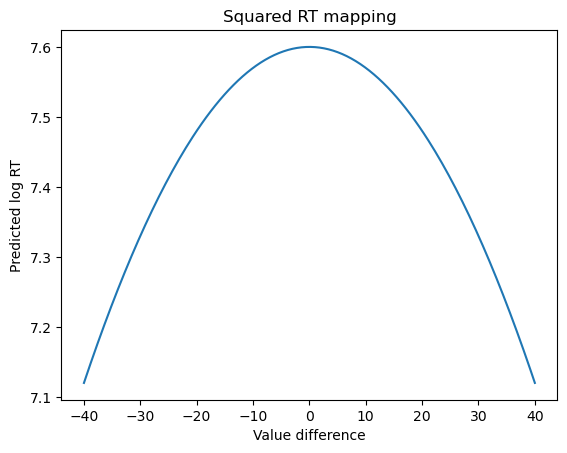

In [17]:
# Sanity check for the squared RT model

v_test = np.linspace(-40, 40, 200)

a_test = 7.6
b_test = 0.0003

mu_test = rt_location(
    v_test,
    a_test,
    b_test,
    rt_model="squared"
)

plt.plot(v_test, mu_test)
plt.xlabel("Value difference")
plt.ylabel("Predicted log RT")
plt.title("Squared RT mapping")
plt.show()

## Likelihood

I first define the choice and RT log-likelihoods separately. This
makes it easier to check the two modalities and later allows me to
fit the required choice-only baseline.

### Choice log-likelihood

For the logistic choice model, define

$$
\eta_i = \beta \Delta V_i.
$$

The choice log-likelihood is

$$
\ell_{choice}(k,\beta)
=
\sum_i
\left[
x_i\eta_i - \log(1 + \exp(\eta_i))
\right].
$$

In the code, `np.logaddexp(0, eta)` is used to calculate
$\log(1+\exp(\eta))$ without numerical overflow.

### RT log-likelihood

The RT log-likelihood is

$$
\ell_{RT}
=
\sum_i
\left[
-\frac{1}{2}\log(2\pi\sigma^2)
-
\frac{(\log RT_i-\mu_i)^2}{2\sigma^2}
\right].
$$

The mean $\mu_i$ is obtained from one of the three RT mappings.

In [18]:
def choice_log_likelihood(df, k, beta):

    choice = df["action(cleaned)"].to_numpy(dtype=float)

    # Compute subjective values using the hyperbolic model
    v_imm, v_del, v_delta = hyperbolic_value(
        df["immOutcome"],
        df["delOutcome"],
        df["delay"],
        k
    )

    v_delta = np.asarray(v_delta, dtype=float)

    # Linear predictor of the logistic choice rule
    eta = beta * v_delta

    # Same log-likelihood formula as in the lecture:
    # x * eta - log(1 + exp(eta))
    trial_log_likelihood = (
        choice * eta
        - np.logaddexp(0.0, eta)
    )

    return np.sum(trial_log_likelihood)

In [19]:
def rt_log_likelihood(df, k, a, b, sigma, rt_model):

    # RT is kept in milliseconds
    rt = df["RT"].to_numpy(dtype=float)

    # The log-normal model requires positive RTs
    if np.any(rt <= 0):
        return -np.inf

    # Standard deviation must be positive
    if sigma <= 0:
        return -np.inf

    # Compute the value difference
    v_imm, v_del, v_delta = hyperbolic_value(
        df["immOutcome"],
        df["delOutcome"],
        df["delay"],
        k
    )

    v_delta = np.asarray(v_delta, dtype=float)

    # Mean of log RT under the selected RT model
    mu_rt = rt_location(
        v_delta,
        a,
        b,
        rt_model
    )

    # Observed log RT
    log_rt = np.log(rt)

    # Gaussian log-likelihood for log RT
    trial_log_likelihood = (
        -0.5 * np.log(2 * np.pi * sigma**2)
        - ((log_rt - mu_rt)**2) / (2 * sigma**2)
    )

    return np.sum(trial_log_likelihood)

In [20]:
def choice_accuracy(df, k, beta):

    choice = df["action(cleaned)"].to_numpy(dtype=int)

    v_imm, v_del, v_delta = hyperbolic_value(
        df["immOutcome"],
        df["delOutcome"],
        df["delay"],
        k
    )

    v_delta = np.asarray(v_delta, dtype=float)

    p_imm, p_del = logistic_choice(
        v_delta,
        beta
    )

    predicted_choice = (p_imm >= 0.5).astype(int)

    return np.mean(predicted_choice == choice)

In [21]:
def joint_log_likelihood(df, k, beta, a, b, sigma, rt_model):
    choice_ll = choice_log_likelihood(df, k, beta)
    rt_ll = rt_log_likelihood(df, k, a, b, sigma, rt_model)

    return choice_ll + rt_ll

In [22]:
def l2_penalty(k, beta):
    # Use log ratios because k and beta are positive and have very different scales
    scaled_k = np.log(k / K_CENTER)
    scaled_beta = np.log(beta / BETA_CENTER)

    # b is not penalized because zero-centred L2 would push weak b estimates toward zero
    return scaled_k**2 + scaled_beta**2


def negative_choice_log_likelihood(params, df, l2_lambda):
    k, beta = params

    # Use mean NLL so the meaning of lambda does not depend strongly on trial count
    choice_nll_per_trial = -choice_log_likelihood(df, k, beta) / len(df)

    penalty = l2_lambda * l2_penalty(k, beta)

    return choice_nll_per_trial + penalty


def negative_joint_log_likelihood(params, df, rt_model, l2_lambda):
    k, beta, a, b, sigma = params

    joint_ll = joint_log_likelihood(
        df=df,
        k=k,
        beta=beta,
        a=a,
        b=b,
        sigma=sigma,
        rt_model=rt_model
    )

    # The penalty is added to the fitting objective, not to accuracy or test likelihood
    joint_nll_per_trial = -joint_ll / len(df)
    penalty = l2_lambda * l2_penalty(k, beta)

    return joint_nll_per_trial + penalty

In [23]:
def minimize_with_multiple_starts(objective_function, starting_values, args, bounds):
    successful_results = []

    for initial_values in starting_values:
        result = minimize(
            objective_function,
            x0=initial_values,
            args=args,
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 2000}
        )

        if result.success and np.isfinite(result.fun):
            successful_results.append(result)

    if len(successful_results) == 0:
        raise RuntimeError("Optimization failed for all starting values.")

    best_result = min(
        successful_results,
        key=lambda result: result.fun
    )

    return best_result

## Inference on Run A

I first fit the three full choice and RT models to Run A for one
participant as a check of the optimisation procedure. I then apply
the same fitting procedure to all participants.

In [24]:
participant_index = 0
participant_train = cleaned_data[participant_index]["train"]
participant_test = cleaned_data[participant_index]["test"]

print("Run A trials:", len(participant_train))
print("Run B trials:", len(participant_test))

Run A trials: 79
Run B trials: 177


In [25]:
# Keep a positive lower bound because log(k) and log(beta) are used in the penalty
SMALL_POSITIVE = 1e-6

# Keep the original upper bound as an additional numerical safeguard
BETA_UPPER_BOUND = 20

# Reference values used to put k and beta on comparable scales
# These are the middle values already used in the starting values and recovery design
K_CENTER = 0.01
BETA_CENTER = 1.0

# Candidate penalty strengths; lambda will be selected using Run A only
LAMBDA_VALUES = [
    0.0,
    0.0001,
    0.0003,
    0.001,
    0.003,
    0.01,
    0.03,
    0.1
]

In [26]:
full_initial_params = {
    "absolute": [
        0.01,  # k
        0.1,   # beta
        7.6,   # a
        0.01,  # b
        0.4    # sigma
    ],

    "squared": [
        0.01,
        0.1,
        7.6,
        0.0003,
        0.4
    ],

    "exponential": [
        0.01,
        0.1,
        7.3,
        0.3,
        0.4
    ]
}

In [27]:
full_bounds = [
    (SMALL_POSITIVE, None),              # k
    (SMALL_POSITIVE, BETA_UPPER_BOUND),  # beta
    (None, None),                        # a
    (0, None),                           # b
    (SMALL_POSITIVE, None)               # sigma
]

In [28]:
# Starting values for the choice-only model
choice_starting_values = [
    [0.001, 0.1],
    [0.01, 1.0],
    [0.1, 5.0]
]

choice_bounds = [
    (SMALL_POSITIVE, None),
    (SMALL_POSITIVE, BETA_UPPER_BOUND)
]

In [29]:
def make_folds(df, n_folds, seed):
    random_generator = np.random.default_rng(seed)
    shuffled_index = random_generator.permutation(len(df))

    return np.array_split(shuffled_index, n_folds)


def choose_l2_lambda(data_list, lambda_values, n_folds=3, seed=1):
    cv_rows = []

    for l2_lambda in lambda_values:
        total_validation_nll = 0
        total_validation_correct = 0
        total_validation_trials = 0

        print("Testing lambda:", l2_lambda)

        for participant_number, participant in enumerate(data_list):
            df = participant["train"].reset_index(drop=True)
            folds = make_folds(df, n_folds, seed + participant_number)

            for fold_number in range(n_folds):
                validation_index = folds[fold_number]

                training_index = np.concatenate([
                    folds[index]
                    for index in range(n_folds)
                    if index != fold_number
                ])

                training_df = df.iloc[training_index]
                validation_df = df.iloc[validation_index]

                result = minimize_with_multiple_starts(
                    objective_function=negative_choice_log_likelihood,
                    starting_values=choice_starting_values,
                    args=(training_df, l2_lambda),
                    bounds=choice_bounds
                )

                k, beta = result.x

                # Evaluate validation data without including the penalty
                validation_nll = -choice_log_likelihood(
                    validation_df,
                    k,
                    beta
                )

                validation_accuracy = choice_accuracy(
                    validation_df,
                    k,
                    beta
                )

                total_validation_nll += validation_nll
                total_validation_correct += validation_accuracy * len(validation_df)
                total_validation_trials += len(validation_df)

        cv_rows.append({
            "l2_lambda": l2_lambda,
            "validation_nll_per_trial": total_validation_nll / total_validation_trials,
            "validation_accuracy": total_validation_correct / total_validation_trials
        })

    cv_results = pd.DataFrame(cv_rows)

    # Log-likelihood is primary; accuracy is used only to break close ties
    cv_results = cv_results.sort_values(
        ["validation_nll_per_trial", "validation_accuracy"],
        ascending=[True, False]
    ).reset_index(drop=True)

    best_lambda = float(cv_results.loc[0, "l2_lambda"])

    return cv_results, best_lambda


# Select one common lambda using Run A only
cv_results, best_lambda = choose_l2_lambda(
    data_list=cleaned_data,
    lambda_values=LAMBDA_VALUES,
    n_folds=3,
    seed=1
)

display(cv_results)
print("Selected L2 lambda:", best_lambda)

Testing lambda: 0.0


C:\Users\Tony_Du\AppData\Local\Temp\ipykernel_75552\988445024.py:2: RuntimeWarning: overflow encountered in exp
  p_imm = 1 / (1 + np.exp(-beta * v_delta))


Testing lambda: 0.0001
Testing lambda: 0.0003
Testing lambda: 0.001
Testing lambda: 0.003
Testing lambda: 0.01
Testing lambda: 0.03
Testing lambda: 0.1


,l2_lambda,validation_nll_per_trial,validation_accuracy
0,0.0300,0.518555,0.862143
1,0.0100,0.546946,0.863943
2,0.1000,0.564696,0.846050
3,0.0030,0.638206,0.865856
4,0.0010,0.762341,0.864844
5,0.0003,0.880875,0.865519
6,0.0001,0.990146,0.864956
7,0.0000,1.058048,0.863943


Selected L2 lambda: 0.03


In [30]:
full_results = {}

for rt_model, initial_params in full_initial_params.items():

    starting_values = [
        [
            0.001,
            0.1,
            initial_params[2],
            initial_params[3],
            initial_params[4]
        ],
        [
            0.01,
            1.0,
            initial_params[2],
            initial_params[3],
            initial_params[4]
        ],
        [
            0.1,
            5.0,
            initial_params[2],
            initial_params[3],
            initial_params[4]
        ]
    ]

    print("\nRT model:", rt_model)

    result = minimize_with_multiple_starts(
        objective_function=negative_joint_log_likelihood,
        starting_values=starting_values,
        args=(participant_train, rt_model, best_lambda),
        bounds=full_bounds
    )
    full_results[rt_model] = result
    
    raw_joint_nll = -joint_log_likelihood(
        participant_train,
        result.x[0],
        result.x[1],
        result.x[2],
        result.x[3],
        result.x[4],
        rt_model
    )

    print("Final success:", result.success)
    print("Final message:", result.message)
    print("Best regularized loss:", result.fun)
    print("Raw training joint NLL:", raw_joint_nll)
    print("Estimated parameters:", result.x)


RT model: absolute
Final success: True
Final message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
Best regularized loss: 1.0450006634621543
Raw training joint NLL: 80.48150225505033
Estimated parameters: [1.18710355e-02 3.98714541e-01 7.58844552e+00 4.50480322e-03
 4.19160584e-01]

RT model: squared
Final success: True
Final message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Best regularized loss: 1.045240546062618
Raw training joint NLL: 80.49892912237684
Estimated parameters: [1.18823632e-02 3.98646282e-01 7.57412188e+00 1.29295990e-04
 4.19263896e-01]

RT model: exponential
Final success: True
Final message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Best regularized loss: 1.0435226158118585
Raw training joint NLL: 80.47012920110652
Estimated parameters: [0.01062258 0.40281232 7.51736351 0.13961333 0.41744102]


### choice-only definition and Run A fit

In [31]:
choice_only_result = minimize_with_multiple_starts(
    objective_function=negative_choice_log_likelihood,
    starting_values=choice_starting_values,
    args=(participant_train, best_lambda),
    bounds=choice_bounds
)

choice_only_k, choice_only_beta = choice_only_result.x

raw_choice_nll = -choice_log_likelihood(
    participant_train,
    choice_only_k,
    choice_only_beta
)

print("Success:", choice_only_result.success)
print("Message:", choice_only_result.message)
print("Regularized loss:", choice_only_result.fun)
print("Raw training choice NLL:", raw_choice_nll)
print("Estimated k:", choice_only_k)
print("Estimated beta:", choice_only_beta)

Success: True
Message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
Regularized loss: 0.4955047445151065
Raw training choice NLL: 37.037370640020875
Estimated k: 0.012110351122666594
Estimated beta: 0.39718533376035714


### Participant-level Run A fitting

I now apply the same Run A fitting procedure to all participants.
The fitted parameters are stored for later recovery, reliability and
Run B evaluation. Run B is not used during this inference step.

In [32]:
def model_fitting(participant, run, l2_lambda):
    df = participant[run]
    participant_id = participant["participant_id"]

    result_rows = []

    # Fit the regularized choice-only model
    choice_only_result = minimize_with_multiple_starts(
        objective_function=negative_choice_log_likelihood,
        starting_values=choice_starting_values,
        args=(df, l2_lambda),
        bounds=choice_bounds
    )

    choice_k, choice_beta = choice_only_result.x

    # Store the raw NLL separately from the regularized fitting objective
    choice_train_nll = -choice_log_likelihood(
        df,
        choice_k,
        choice_beta
    )

    result_rows.append({
        "participant_id": participant_id,
        "model": "choice_only",
        "success": choice_only_result.success,
        "train_nll": choice_train_nll,
        "regularized_loss": choice_only_result.fun,
        "l2_lambda": l2_lambda,
        "k": choice_k,
        "beta": choice_beta,
        "a": np.nan,
        "b": np.nan,
        "sigma": np.nan
    })

    # Fit the three regularized choice + RT models
    for rt_model, initial_params in full_initial_params.items():
        starting_values = [
            [0.001, 0.1, initial_params[2], initial_params[3], initial_params[4]],
            [0.01, 1.0, initial_params[2], initial_params[3], initial_params[4]],
            [0.1, 5.0, initial_params[2], initial_params[3], initial_params[4]]
        ]

        full_result = minimize_with_multiple_starts(
            objective_function=negative_joint_log_likelihood,
            starting_values=starting_values,
            args=(df, rt_model, l2_lambda),
            bounds=full_bounds
        )

        k, beta, a, b, sigma = full_result.x

        # Raw NLL is used for reporting and model evaluation
        full_train_nll = -joint_log_likelihood(
            df,
            k,
            beta,
            a,
            b,
            sigma,
            rt_model
        )

        result_rows.append({
            "participant_id": participant_id,
            "model": rt_model,
            "success": full_result.success,
            "train_nll": full_train_nll,
            "regularized_loss": full_result.fun,
            "l2_lambda": l2_lambda,
            "k": k,
            "beta": beta,
            "a": a,
            "b": b,
            "sigma": sigma
        })

    return pd.DataFrame(result_rows)

In [33]:
all_result_tables = []
failed_participants = []

for index, participant in enumerate(cleaned_data):

    print(
        "\nParticipant",
        index + 1,
        "of",
        len(cleaned_data)
    )

    try:
        participant_result = model_fitting(
            participant, run="train", l2_lambda=best_lambda
        )

        all_result_tables.append(participant_result)

    except RuntimeError as error:
        failed_participants.append({
            "participant_id": participant["participant_id"],
            "error": str(error)
        })

all_results = pd.concat(
    all_result_tables,
    ignore_index=True
)

print("Number of result rows:", len(all_results))
print("Failed participants:", len(failed_participants))

pd.DataFrame(failed_participants)


Participant 1 of 99

Participant 2 of 99

Participant 3 of 99

Participant 4 of 99

Participant 5 of 99

Participant 6 of 99

Participant 7 of 99

Participant 8 of 99

Participant 9 of 99

Participant 10 of 99

Participant 11 of 99

Participant 12 of 99

Participant 13 of 99

Participant 14 of 99

Participant 15 of 99

Participant 16 of 99

Participant 17 of 99

Participant 18 of 99

Participant 19 of 99

Participant 20 of 99

Participant 21 of 99

Participant 22 of 99

Participant 23 of 99

Participant 24 of 99

Participant 25 of 99

Participant 26 of 99

Participant 27 of 99

Participant 28 of 99

Participant 29 of 99

Participant 30 of 99

Participant 31 of 99

Participant 32 of 99

Participant 33 of 99

Participant 34 of 99

Participant 35 of 99

Participant 36 of 99

Participant 37 of 99

Participant 38 of 99

Participant 39 of 99

Participant 40 of 99

Participant 41 of 99

Participant 42 of 99

Participant 43 of 99

Participant 44 of 99

Participant 45 of 99

Participant 46 of 

""


In [34]:
all_results.groupby("model")["participant_id"].nunique()

parameter_summary = (
    all_results
    .groupby("model")[["k", "beta", "a", "b", "sigma"]]
    .agg(["min", "median", "max"])
)

parameter_summary

k                          beta                      \
                  min    median       max       min    median       max   
model                                                                     
absolute     0.000567  0.008308  0.063658  0.068407  0.578454  2.514140   
choice_only  0.000578  0.008056  0.058643  0.068139  0.577616  2.521912   
exponential  0.000529  0.009236  0.068088  0.067827  0.612480  2.534289   
squared      0.000570  0.008049  0.061249  0.068298  0.577616  2.517515   

                    a                        b                         sigma  \
                  min    median       max  min    median       max       min   
model                                                                          
absolute     6.755190  7.538179  8.039204  0.0  0.003777  0.017726  0.190266   
choice_only       NaN       NaN       NaN  NaN       NaN       NaN       NaN   
exponential  6.721009  7.434590  7.915629  0.0  0.202507  0.829370  0.190269   
squared      6.743212  7.512189  8.016027  0.0  0.000039  0.000326  0.190266   

                                 
               median       max  
model                            
absolute     0.321553  0.526946  
choice_only       NaN       NaN  
exponential  0.315915  0.506314  
squared      0.324421  0.526946

In [35]:
all_results["beta_at_bound"] = np.isclose(all_results["beta"], BETA_UPPER_BOUND)

beta_bound_counts = (all_results .groupby("model")["beta_at_bound"] .sum()
)

beta_bound_counts

model
absolute       0
choice_only    0
exponential    0
squared        0
Name: beta_at_bound, dtype: int64

## Parameter recovery

Parameter recovery checks whether the fitting procedure can recover
the parameter values used to generate simulated data. These generating
values are chosen before the simulation and are therefore known. They
are not the known psychological parameters of a real participant.

For each RT model, I use observed Run A trial designs from different
participants and simulate new choices and RTs. I use parameter values covering low,
medium, and high ranges and repeat each condition several times. Each
simulated data set is fitted with both the choice-only model and the
corresponding full choice + RT model.

I compare recovery of `k` and `beta` between the two fits and examine
recovery of the RT parameters `a`, `b`, and `sigma`. This assesses
practical parameter recovery under the current finite data set. It is
not a proof of structural identifiability.

In [36]:
def simulate_choice_rt_data(data, k, beta, a, b, sigma, rt_model):

    # Copy the real trial design before generating synthetic responses
    syn_data = data.copy()

    # Compute value difference using the generating k
    v_imm, v_del, v_delta = hyperbolic_value(
        syn_data["immOutcome"],
        syn_data["delOutcome"],
        syn_data["delay"],
        k
    )

    v_delta = np.asarray(
        v_delta,
        dtype=float
    )

    # Generate synthetic choices from the logistic choice rule
    syn_p_imm, syn_p_del = logistic_choice(
        v_delta,
        beta
    )

    syn_choice = np.random.binomial(
        n=1,
        p=syn_p_imm
    )

    # Compute the generating mean of log RT
    syn_mu_rt = rt_location(
        v_delta,
        a,
        b,
        rt_model
    )

    # Generate synthetic log RT
    syn_log_rt = np.random.normal(
        loc=syn_mu_rt,
        scale=sigma
    )

    # Convert synthetic log RT back to milliseconds
    syn_rt = np.exp(
        syn_log_rt
    )

    # Replace the original observed choice and RT
    syn_data["action(cleaned)"] = syn_choice

    syn_data[
        "action (1=immediate, 2=delayed, 0=missing)"
    ] = np.where(
        syn_choice == 1,
        1,
        2
    )

    syn_data["RT"] = syn_rt

    return syn_data

In [37]:
def run_parameter_recovery(rt_model, generating_parameters, n_repetitions, l2_lambda, data):

    design_indices = np.random.choice(
        len(data),
        size=n_repetitions,
        replace=n_repetitions > len(data)
    )
    initial_params = full_initial_params[rt_model]
    recovery_starting_values = [
        [
            0.001,
            0.1,
            initial_params[2],
            initial_params[3],
            initial_params[4]
        ],
        [
            0.01,
            1.0,
            initial_params[2],
            initial_params[3],
            initial_params[4]
        ],
        [
            0.1,
            5.0,
            initial_params[2],
            initial_params[3],
            initial_params[4]
        ]
    ]

    recovery_rows = []

    for parameter_set in generating_parameters:
        print("Generating parameters:", parameter_set["parameter_range"], rt_model)

        for repetition in range(1, n_repetitions + 1):

            run_index = int(design_indices[repetition - 1])
            run_participant = data[run_index]
            run_data = run_participant["train"]
            syn_data = simulate_choice_rt_data(
                run_data,
                parameter_set["k"],
                parameter_set["beta"],
                parameter_set["a"],
                parameter_set["b"],
                parameter_set["sigma"],
                rt_model
            )
            choice_fit = minimize_with_multiple_starts(
                negative_choice_log_likelihood,
                choice_starting_values,
                args=(syn_data, l2_lambda),
                bounds=choice_bounds
            )

            full_fit = minimize_with_multiple_starts(
                negative_joint_log_likelihood,
                recovery_starting_values,
                args=(syn_data, rt_model, l2_lambda),
                bounds=full_bounds
            )

            recovery_rows.append({
                "design_participant_id": run_participant["participant_id"],
                "n_trials": len(run_data),
                "model": rt_model,
                "parameter_range":
                    parameter_set["parameter_range"],
                "repetition": repetition,

                "true_k": parameter_set["k"],
                "choice_k": choice_fit.x[0],
                "full_k": full_fit.x[0],

                "true_beta": parameter_set["beta"],
                "choice_beta": choice_fit.x[1],
                "full_beta": full_fit.x[1],

                "true_a": parameter_set["a"],
                "full_a": full_fit.x[2],

                "true_b": parameter_set["b"],
                "full_b": full_fit.x[3],

                "true_sigma": parameter_set["sigma"],
                "full_sigma": full_fit.x[4],

                "choice_success": choice_fit.success,
                "full_success": full_fit.success
            })

    recovery_results = pd.DataFrame(recovery_rows)

    # Absolute recovery errors

    recovery_results["choice_k_error"] = np.abs(
        recovery_results["choice_k"]
        - recovery_results["true_k"]
    )

    recovery_results["full_k_error"] = np.abs(
        recovery_results["full_k"]
        - recovery_results["true_k"]
    )

    recovery_results["choice_beta_error"] = np.abs(
        recovery_results["choice_beta"]
        - recovery_results["true_beta"]
    )

    recovery_results["full_beta_error"] = np.abs(
        recovery_results["full_beta"]
        - recovery_results["true_beta"]
    )

    recovery_results["full_a_error"] = np.abs(
        recovery_results["full_a"]
        - recovery_results["true_a"]
    )

    recovery_results["full_b_error"] = np.abs(
        recovery_results["full_b"]
        - recovery_results["true_b"]
    )

    recovery_results["full_sigma_error"] = np.abs(
        recovery_results["full_sigma"]
        - recovery_results["true_sigma"]
    )

    # Relative recovery errors

    recovery_results["choice_k_relative_error"] = (
        recovery_results["choice_k_error"]
        / recovery_results["true_k"]
    )

    recovery_results["full_k_relative_error"] = (
        recovery_results["full_k_error"]
        / recovery_results["true_k"]
    )

    recovery_results["choice_beta_relative_error"] = (
        recovery_results["choice_beta_error"]
        / recovery_results["true_beta"]
    )

    recovery_results["full_beta_relative_error"] = (
        recovery_results["full_beta_error"]
        / recovery_results["true_beta"]
    )

    recovery_results["full_a_relative_error"] = (
        recovery_results["full_a_error"]
        / recovery_results["true_a"]
    )

    recovery_results["full_b_relative_error"] = (
        recovery_results["full_b_error"]
        / recovery_results["true_b"]
    )

    recovery_results["full_sigma_relative_error"] = (
        recovery_results["full_sigma_error"]
        / recovery_results["true_sigma"]
    )

    # Does adding RT improve recovery?

    recovery_results["k_relative_improvement"] = (
        recovery_results["choice_k_relative_error"]
        - recovery_results["full_k_relative_error"]
    )

    recovery_results["beta_relative_improvement"] = (
        recovery_results["choice_beta_relative_error"]
        - recovery_results["full_beta_relative_error"]
    )

    # Parameter-boundary checks

    recovery_results["choice_beta_at_bound"] = np.isclose(
        recovery_results["choice_beta"],
        BETA_UPPER_BOUND
    )

    recovery_results["full_beta_at_bound"] = np.isclose(
        recovery_results["full_beta"],
        BETA_UPPER_BOUND
    )

    recovery_results["b_at_zero"] = np.isclose(
        recovery_results["full_b"],
        0
    )

    return recovery_results

### Recovery for the squared RT model

I first examine parameter recovery for the squared RT model. The
observed Run A estimates are used only to select approximately
realistic generating parameter ranges.

In [38]:
squared_fitted_parameters = all_results.loc[
    all_results["model"] == "squared",
    ["k", "beta", "a", "b", "sigma"]
]

squared_fitted_parameters.quantile([0.10, 0.50, 0.90])

,k,beta,a,b,sigma
0.1,0.000955,0.204102,7.159126,0.000000,0.250984
0.5,0.008049,0.577616,7.512189,0.000039,0.324421
0.9,0.025268,1.855696,7.777314,0.000150,0.419416


In [39]:
squared_generating_parameters = [
    {
        "parameter_range": "low",
        "k": 0.001,
        "beta": 0.3,
        "a": 7.2,
        "b": 0.00002,
        "sigma": 0.25
    },
    {
        "parameter_range": "medium",
        "k": 0.01,
        "beta": 1.0,
        "a": 7.5,
        "b": 0.00005,
        "sigma": 0.35
    },
    {
        "parameter_range": "high",
        "k": 0.025,
        "beta": 2.0,
        "a": 7.8,
        "b": 0.00015,
        "sigma": 0.42
    }
]

In [40]:
n_repetitions = 50

np.random.seed(1)

squared_recovery_results = run_parameter_recovery(
    rt_model="squared",
    generating_parameters=squared_generating_parameters,
    n_repetitions=n_repetitions, l2_lambda=best_lambda, data=cleaned_data
)

print(
    "Number of squared recovery fits:",
    len(squared_recovery_results)
)

squared_recovery_results.head()

Generating parameters: low squared
Generating parameters: medium squared
Generating parameters: high squared
Number of squared recovery fits: 150


,design_participant_id,n_trials,model,parameter_range,repetition,true_k,choice_k,full_k,true_beta,choice_beta,...,choice_beta_relative_error,full_beta_relative_error,full_a_relative_error,full_b_relative_error,full_sigma_relative_error,k_relative_improvement,beta_relative_improvement,choice_beta_at_bound,full_beta_at_bound,b_at_zero
0,93,100,squared,low,1,0.001,0.002101,0.002020,0.3,0.364828,...,0.216092,0.241328,0.001719,1.284102,0.135717,0.080587,-0.025236,False,False,False
1,84,100,squared,low,2,0.001,0.001196,0.001230,0.3,0.538870,...,0.796232,0.748208,0.007144,0.539930,0.111529,-0.033388,0.048024,False,False,False
2,33,80,squared,low,3,0.001,0.001685,0.001685,0.3,0.361553,...,0.205176,0.205178,0.004872,1.000000,0.095889,0.000006,-0.000002,False,False,True
3,81,100,squared,low,4,0.001,0.001219,0.001221,0.3,0.461744,...,0.539146,0.537551,0.002941,0.795245,0.086910,-0.001456,0.001595,False,False,False
4,79,100,squared,low,5,0.001,0.001330,0.001310,0.3,0.407262,...,0.357539,0.372888,0.001375,0.636683,0.000374,0.019104,-0.015350,False,False,False


## Absilute recovery

In [41]:
absolute_fitted_parameters = all_results.loc[
    all_results["model"] == "absolute",
    ["k", "beta", "a", "b", "sigma"]
]

absolute_fitted_parameters.quantile([0.10, 0.50, 0.90])

,k,beta,a,b,sigma
0.1,0.000952,0.202789,7.170446,0.000000,0.249176
0.5,0.008308,0.578454,7.538179,0.003777,0.321553
0.9,0.025099,1.863745,7.810286,0.007314,0.419282


In [42]:
absolute_generating_parameters = [
    {
        "parameter_range": "low",
        "k": 0.001,
        "beta": 0.3,
        "a": 7.2,
        "b": 0.001,
        "sigma": 0.25
    },
    {
        "parameter_range": "medium",
        "k": 0.01,
        "beta": 1.0,
        "a": 7.5,
        "b": 0.004,
        "sigma": 0.35
    },
    {
        "parameter_range": "high",
        "k": 0.025,
        "beta": 2.0,
        "a": 7.8,
        "b": 0.007,
        "sigma": 0.4
    }
]

In [43]:
np.random.seed(1)

absolute_recovery_results = run_parameter_recovery(
    rt_model="absolute",
    generating_parameters=absolute_generating_parameters,
    n_repetitions=n_repetitions, l2_lambda=best_lambda, data=cleaned_data
)

print(
    "Number of absolute recovery fits:",
    len(absolute_recovery_results)
)

absolute_recovery_results.head()

Generating parameters: low absolute
Generating parameters: medium absolute
Generating parameters: high absolute
Number of absolute recovery fits: 150


,design_participant_id,n_trials,model,parameter_range,repetition,true_k,choice_k,full_k,true_beta,choice_beta,...,choice_beta_relative_error,full_beta_relative_error,full_a_relative_error,full_b_relative_error,full_sigma_relative_error,k_relative_improvement,beta_relative_improvement,choice_beta_at_bound,full_beta_at_bound,b_at_zero
0,93,100,absolute,low,1,0.001,0.002101,0.002042,0.3,0.364828,...,0.216092,0.234480,0.003066,1.724131,0.135484,0.059199,-0.018388,False,False,False
1,84,100,absolute,low,2,0.001,0.001196,0.001208,0.3,0.538870,...,0.796232,0.779868,0.007087,0.415066,0.109222,-0.011241,0.016365,False,False,False
2,33,80,absolute,low,3,0.001,0.001685,0.001685,0.3,0.361553,...,0.205176,0.205178,0.004386,1.000000,0.095939,0.000005,-0.000003,False,False,True
3,81,100,absolute,low,4,0.001,0.001219,0.001220,0.3,0.461744,...,0.539146,0.538766,0.002623,0.963401,0.088751,-0.000340,0.000381,False,False,False
4,79,100,absolute,low,5,0.001,0.001330,0.001314,0.3,0.407262,...,0.357539,0.369717,0.001043,0.312860,0.002600,0.015164,-0.012179,False,False,False


# Exponential recovery

In [44]:
exponential_fitted_parameters = all_results.loc[
    all_results["model"] == "exponential",
    ["k", "beta", "a", "b", "sigma"]
]

exponential_fitted_parameters.quantile(
    [0.10, 0.50, 0.90]
)

,k,beta,a,b,sigma
0.1,0.000955,0.204348,7.105026,0.000000,0.240582
0.5,0.009236,0.612480,7.434590,0.202507,0.315915
0.9,0.026968,1.994781,7.660082,0.406141,0.404912


In [45]:
exponential_generating_parameters = [
    {
        "parameter_range": "low",
        "k": 0.001,
        "beta": 0.3,
        "a": 7.2,
        "b": 0.05,
        "sigma": 0.25
    },
    {
        "parameter_range": "medium",
        "k": 0.01,
        "beta": 1.0,
        "a": 7.5,
        "b": 0.2,
        "sigma": 0.35
    },
    {
        "parameter_range": "high",
        "k": 0.025,
        "beta": 2.0,
        "a": 7.8,
        "b": 0.4,
        "sigma": 0.4
    }
]

In [46]:
np.random.seed(1)

exponential_recovery_results = run_parameter_recovery(
    rt_model="exponential",
    generating_parameters=exponential_generating_parameters,
    n_repetitions=n_repetitions, l2_lambda=best_lambda, data=cleaned_data
)

print(
    "Number of exponential recovery fits:",
    len(exponential_recovery_results)
)

exponential_recovery_results.head()

Generating parameters: low exponential
Generating parameters: medium exponential
Generating parameters: high exponential
Number of exponential recovery fits: 150


,design_participant_id,n_trials,model,parameter_range,repetition,true_k,choice_k,full_k,true_beta,choice_beta,...,choice_beta_relative_error,full_beta_relative_error,full_a_relative_error,full_b_relative_error,full_sigma_relative_error,k_relative_improvement,beta_relative_improvement,choice_beta_at_bound,full_beta_at_bound,b_at_zero
0,93,100,exponential,low,1,0.001,0.002101,0.002014,0.3,0.364828,...,0.216092,0.243572,0.001632,2.235320,0.139653,0.087522,-2.748033e-02,False,False,False
1,84,100,exponential,low,2,0.001,0.001196,0.001136,0.3,0.538870,...,0.796232,0.886144,0.007499,0.328376,0.109593,0.060521,-8.991164e-02,False,False,False
2,33,80,exponential,low,3,0.001,0.001685,0.001685,0.3,0.361553,...,0.205176,0.205177,0.008035,1.000000,0.107809,0.000003,-9.956414e-07,False,False,True
3,81,100,exponential,low,4,0.001,0.001219,0.001225,0.3,0.461744,...,0.539146,0.533214,0.002151,1.287352,0.081486,-0.005426,5.932004e-03,False,False,False
4,79,100,exponential,low,5,0.001,0.001330,0.001338,0.3,0.407262,...,0.357539,0.350567,0.001508,0.150672,0.000006,-0.008799,6.971617e-03,False,False,False


In [47]:
# Combine all recovery results into a single DataFrame

all_recovery_results = pd.concat(
    [
        squared_recovery_results,
        absolute_recovery_results,
        exponential_recovery_results
    ],
    ignore_index=True
)

print(
    "Total number of recovery fits:",
    len(all_recovery_results)
)

Total number of recovery fits: 450


In [48]:
choice_parameter_recovery = (
    all_recovery_results
    .groupby(["model", "parameter_range"])[
        [
            "choice_k_relative_error",
            "full_k_relative_error",
            "choice_beta_relative_error",
            "full_beta_relative_error"
        ]
    ]
    .mean()
    * 100
)

display(choice_parameter_recovery)

choice_k_relative_error  full_k_relative_error  \
model       parameter_range                                                   
absolute    high                           23.007886              21.942582   
            low                            73.900229              73.767503   
            medium                          5.232983               5.150010   
exponential high                           23.007886              20.362498   
            low                            73.900229              71.352569   
            medium                          5.232983               4.362510   
squared     high                           23.007886              20.219380   
            low                            73.900229              73.688944   
            medium                          5.232983               5.131278   

                             choice_beta_relative_error  \
model       parameter_range                               
absolute    high                              18.015323   
            low                               34.160574   
            medium                            16.211966   
exponential high                              18.015323   
            low                               34.160574   
            medium                            16.211966   
squared     high                              18.015323   
            low                               34.160574   
            medium                            16.211966   

                             full_beta_relative_error  
model       parameter_range                            
absolute    high                            18.485397  
            low                             34.051654  
            medium                          16.170821  
exponential high                            18.609167  
            low                             35.249212  
            medium                          16.092877  
squared     high                            18.937379  
            low                             34.076044  
            medium                          16.274883

In [49]:
rt_parameter_recovery = (
    all_recovery_results
    .groupby(["model", "parameter_range"])[
        [
            "full_a_relative_error",
            "full_b_relative_error",
            "full_sigma_relative_error"
        ]
    ]
    .mean()
    * 100
)

display(rt_parameter_recovery)

full_a_relative_error  full_b_relative_error  \
model       parameter_range                                                 
absolute    high                          0.545543              34.222974   
            low                           0.309586             107.921376   
            medium                        0.458703              56.197127   
exponential high                          0.555274              49.421610   
            low                           0.317014             103.823493   
            medium                        0.520235              36.194569   
squared     high                          0.527695              38.348878   
            low                           0.278137             108.323695   
            medium                        0.412479              86.616741   

                             full_sigma_relative_error  
model       parameter_range                             
absolute    high                              5.515299  
            low                               7.000681  
            medium                            5.685333  
exponential high                              5.532684  
            low                               6.857523  
            medium                            5.629965  
squared     high                              5.564134  
            low                               7.026253  
            medium                            5.645476

In [50]:
recovery_improvement = (
    all_recovery_results
    .groupby(["model", "parameter_range"])[
        [
            "k_relative_improvement",
            "beta_relative_improvement"
        ]
    ]
    .mean()
    * 100
)

display(recovery_improvement)

k_relative_improvement  beta_relative_improvement
model       parameter_range                                                   
absolute    high                           1.065304                  -0.470074
            low                            0.132726                   0.108920
            medium                         0.082973                   0.041146
exponential high                           2.645388                  -0.593844
            low                            2.547660                  -1.088638
            medium                         0.870473                   0.119089
squared     high                           2.788506                  -0.922056
            low                            0.211285                   0.084531
            medium                         0.101705                  -0.062917

In [51]:
recovery_boundaries = (
    all_recovery_results
    .groupby(["model", "parameter_range"])[
        [
            "choice_beta_at_bound",
            "full_beta_at_bound",
            "b_at_zero"
        ]
    ]
    .mean()
)

display(recovery_boundaries)

choice_beta_at_bound  full_beta_at_bound  \
model       parameter_range                                             
absolute    high                              0.0                 0.0   
            low                               0.0                 0.0   
            medium                            0.0                 0.0   
exponential high                              0.0                 0.0   
            low                               0.0                 0.0   
            medium                            0.0                 0.0   
squared     high                              0.0                 0.0   
            low                               0.0                 0.0   
            medium                            0.0                 0.0   

                             b_at_zero  
model       parameter_range             
absolute    high                  0.00  
            low                   0.36  
            medium                0.08  
exponential high                  0.08  
            low                   0.32  
            medium                0.00  
squared     high                  0.02  
            low                   0.38  
            medium                0.18

In [52]:
recovery_fit_success = (
    all_recovery_results
    .groupby("model")[
        [
            "choice_success",
            "full_success"
        ]
    ]
    .mean()
)

display(recovery_fit_success)

,choice_success,full_success
model,,
absolute,1.0,1.0
exponential,1.0,1.0
squared,1.0,1.0


## Reliability

In [53]:
run_b_result_tables = []
failed_run_b_participants = []

for index, participant in enumerate(cleaned_data):

    print(
        "\nRun B participant",
        index + 1,
        "of",
        len(cleaned_data)
    )

    try:
        participant_result = model_fitting(
            participant,
            run="test", l2_lambda=best_lambda
        )

        run_b_result_tables.append(
            participant_result
        )

    except RuntimeError as error:
        failed_run_b_participants.append({
            "participant_id": participant["participant_id"],
            "error": str(error)
        })

run_b_reliability_results = pd.concat(
    run_b_result_tables,
    ignore_index=True
)

print(
    "Number of Run B result rows:",
    len(run_b_reliability_results)
)

print(
    "Failed Run B participants:",
    len(failed_run_b_participants)
)

pd.DataFrame(failed_run_b_participants)


Run B participant 1 of 99

Run B participant 2 of 99

Run B participant 3 of 99

Run B participant 4 of 99

Run B participant 5 of 99

Run B participant 6 of 99

Run B participant 7 of 99

Run B participant 8 of 99

Run B participant 9 of 99

Run B participant 10 of 99

Run B participant 11 of 99

Run B participant 12 of 99

Run B participant 13 of 99

Run B participant 14 of 99

Run B participant 15 of 99

Run B participant 16 of 99

Run B participant 17 of 99

Run B participant 18 of 99

Run B participant 19 of 99

Run B participant 20 of 99

Run B participant 21 of 99

Run B participant 22 of 99

Run B participant 23 of 99

Run B participant 24 of 99

Run B participant 25 of 99

Run B participant 26 of 99

Run B participant 27 of 99

Run B participant 28 of 99

Run B participant 29 of 99

Run B participant 30 of 99

Run B participant 31 of 99

Run B participant 32 of 99

Run B participant 33 of 99

Run B participant 34 of 99

Run B participant 35 of 99

Run B participant 36 of 99



""


In [54]:
run_b_fit_summary = (
    run_b_reliability_results
    .groupby("model")
    .agg(
        n_participants=("participant_id", "nunique"),
        success_proportion=("success", "mean")
    )
)

display(run_b_fit_summary)

,n_participants,success_proportion
model,,
absolute,99,1.0
choice_only,99,1.0
exponential,99,1.0
squared,99,1.0


In [55]:
reliability_pairs = all_results.merge(
    run_b_reliability_results,
    on=["participant_id", "model"],
    suffixes=("_run_a", "_run_b")
)

print(
    "Number of matched rows:",
    len(reliability_pairs)
)

reliability_pairs.head()

Number of matched rows: 396


,participant_id,model,success_run_a,train_nll_run_a,regularized_loss_run_a,l2_lambda_run_a,k_run_a,beta_run_a,a_run_a,b_run_a,...,beta_at_bound,success_run_b,train_nll_run_b,regularized_loss_run_b,l2_lambda_run_b,k_run_b,beta_run_b,a_run_b,b_run_b,sigma_run_b
0,1,choice_only,True,37.037371,0.495505,0.03,0.012110,0.397185,NaN,NaN,...,False,True,89.933316,0.554700,0.03,0.020489,0.360860,NaN,NaN,NaN
1,1,absolute,True,80.481502,1.045001,0.03,0.011871,0.398715,7.588446,0.004505,...,False,True,202.405975,1.187145,0.03,0.018527,0.354858,7.699923,0.027359,0.454365
2,1,squared,True,80.498929,1.045241,0.03,0.011882,0.398646,7.574122,0.000129,...,False,True,203.832643,1.197265,0.03,0.019949,0.359720,7.615313,0.001307,0.459996
3,1,exponential,True,80.470129,1.043523,0.03,0.010623,0.402812,7.517364,0.139613,...,False,True,203.103111,1.190376,0.03,0.017885,0.351691,7.532675,0.338068,0.454957
4,2,choice_only,True,12.689720,0.169035,0.03,0.012201,1.741171,NaN,NaN,...,False,True,72.480437,0.413561,0.03,0.018108,1.107790,NaN,NaN,NaN


In [56]:
reliability_rows = []

model_names = [
    "choice_only",
    "absolute",
    "squared",
    "exponential"
]

for model_name in model_names:

    model_data = reliability_pairs[
        reliability_pairs["model"] == model_name
    ]

    if model_name == "choice_only":
        parameters = ["k", "beta"]
    else:
        parameters = ["k", "beta", "a", "b", "sigma"]

    for parameter in parameters:

        run_a_column = parameter + "_run_a"
        run_b_column = parameter + "_run_b"

        parameter_pairs = model_data[
            [run_a_column, run_b_column]
        ].dropna()

        # Rank-order stability across participants
        spearman_r = parameter_pairs[
            run_a_column
        ].corr(
            parameter_pairs[run_b_column],
            method="spearman"
        )

        # Typical numerical difference between runs
        median_absolute_difference = np.median(
            np.abs(
                parameter_pairs[run_a_column]
                - parameter_pairs[run_b_column]
            )
        )

        reliability_rows.append({
            "model": model_name,
            "parameter": parameter,
            "n_participants": len(parameter_pairs),
            "spearman_r": spearman_r,
            "median_absolute_difference":
                median_absolute_difference
        })

reliability_results = pd.DataFrame(
    reliability_rows
)

display(reliability_results)

,model,parameter,n_participants,spearman_r,median_absolute_difference
0,choice_only,k,99,0.831688,0.003147
1,choice_only,beta,99,0.477786,0.308109
2,absolute,k,99,0.839777,0.003313
3,absolute,beta,99,0.528336,0.317283
4,absolute,a,99,0.792381,0.130941
5,absolute,b,99,0.191599,0.004829
6,absolute,sigma,99,0.508609,0.035932
7,squared,k,99,0.838714,0.003185
8,squared,beta,99,0.526048,0.321047
9,squared,a,99,0.798516,0.136806


In [57]:
choice_parameter_reliability = (
    reliability_results[
        reliability_results["parameter"].isin(
            ["k", "beta"]
        )
    ]
    .pivot(
        index="model",
        columns="parameter",
        values="spearman_r"
    )
)

display(choice_parameter_reliability)

parameter,beta,k
model,,
absolute,0.528336,0.839777
choice_only,0.477786,0.831688
exponential,0.527062,0.820136
squared,0.526048,0.838714


In [58]:
rt_parameter_reliability = (
    reliability_results[
        reliability_results["parameter"].isin(
            ["a", "b", "sigma"]
        )
    ]
    .pivot(
        index="model",
        columns="parameter",
        values="spearman_r"
    )
)

display(rt_parameter_reliability)

parameter,a,b,sigma
model,,,
absolute,0.792381,0.191599,0.508609
exponential,0.775622,0.180935,0.519233
squared,0.798516,0.091522,0.508460


In [59]:
parameter_difference_table = (
    reliability_results
    .pivot(
        index="model",
        columns="parameter",
        values="median_absolute_difference"
    )
)

display(parameter_difference_table)

parameter,a,b,beta,k,sigma
model,,,,,
absolute,0.130941,0.004829,0.317283,0.003313,0.035932
choice_only,NaN,NaN,0.308109,0.003147,NaN
exponential,0.118587,0.147350,0.348028,0.003341,0.034435
squared,0.136806,0.000126,0.321047,0.003185,0.037534


In [60]:
reliability_pairs["beta_at_bound_run_a"] = np.isclose(
    reliability_pairs["beta_run_a"],
    BETA_UPPER_BOUND
)

reliability_pairs["beta_at_bound_run_b"] = np.isclose(
    reliability_pairs["beta_run_b"],
    BETA_UPPER_BOUND
)

reliability_pairs["b_at_zero_run_a"] = np.isclose(
    reliability_pairs["b_run_a"],
    0
)

reliability_pairs["b_at_zero_run_b"] = np.isclose(
    reliability_pairs["b_run_b"],
    0
)

reliability_boundary_summary = (
    reliability_pairs
    .groupby("model")[
        [
            "beta_at_bound_run_a",
            "beta_at_bound_run_b",
            "b_at_zero_run_a",
            "b_at_zero_run_b"
        ]
    ]
    .mean()
)

display(reliability_boundary_summary)

,beta_at_bound_run_a,beta_at_bound_run_b,b_at_zero_run_a,b_at_zero_run_b
model,,,,
absolute,0.0,0.0,0.141414,0.363636
choice_only,0.0,0.0,0.000000,0.000000
exponential,0.0,0.0,0.141414,0.161616
squared,0.0,0.0,0.191919,0.383838


## Out-of-sample evaluation on Run B

In [61]:
choice_only_k = choice_only_result.x[0]
choice_only_beta = choice_only_result.x[1]

choice_only_test_ll = choice_log_likelihood(
    df=participant_test,
    k=choice_only_k,
    beta=choice_only_beta
)

choice_only_test_accuracy = choice_accuracy(
    df=participant_test,
    k=choice_only_k,
    beta=choice_only_beta
)

print("Choice-only Run B choice LL:", choice_only_test_ll)
print("Choice-only Run B accuracy:", choice_only_test_accuracy)

Choice-only Run B choice LL: -107.37071715681122
Choice-only Run B accuracy: 0.7570621468926554


In [62]:
comparison_rows = []

comparison_rows.append({
    "model": "choice_only",
    "test_choice_ll": choice_only_test_ll,
    "test_choice_accuracy": choice_only_test_accuracy,
    "test_rt_ll": np.nan
})

for rt_model, result in full_results.items():

    k, beta, a, b, sigma = result.x

    test_choice_ll = choice_log_likelihood(
        df=participant_test,
        k=k,
        beta=beta
    )

    test_choice_accuracy = choice_accuracy(
        df=participant_test,
        k=k,
        beta=beta
    )

    test_rt_ll = rt_log_likelihood(
        df=participant_test,
        k=k,
        a=a,
        b=b,
        sigma=sigma,
        rt_model=rt_model
    )

    comparison_rows.append({
        "model": rt_model,
        "test_choice_ll": test_choice_ll,
        "test_choice_accuracy": test_choice_accuracy,
        "test_rt_ll": test_rt_ll
    })

comparison_table = pd.DataFrame(comparison_rows)
comparison_table

,model,test_choice_ll,test_choice_accuracy,test_rt_ll
0,choice_only,-107.370717,0.757062,NaN
1,absolute,-108.591053,0.762712,-115.607742
2,squared,-108.532161,0.762712,-116.568737
3,exponential,-115.717656,0.762712,-116.154498


In [63]:
# Store each participant's Run B data by participant ID
test_data_by_id = {
    participant["participant_id"]: participant["test"]
    for participant in cleaned_data
}

test_choice_ll_values = []
test_choice_accuracy_values = []
test_rt_ll_values = []

# Evaluate every Run A fit on the corresponding Run B data
for index, fitted_row in all_results.iterrows():

    participant_id = int(
        fitted_row["participant_id"]
    )

    test_df = test_data_by_id[
        participant_id
    ]

    k = fitted_row["k"]
    beta = fitted_row["beta"]

    # Run B choice prediction
    test_choice_ll = choice_log_likelihood(
        df=test_df,
        k=k,
        beta=beta
    )

    test_choice_accuracy = choice_accuracy(
        df=test_df,
        k=k,
        beta=beta
    )

    # The choice-only model does not predict RT
    if fitted_row["model"] == "choice_only":
        test_rt_ll = np.nan

    else:
        test_rt_ll = rt_log_likelihood(
            df=test_df,
            k=k,
            a=fitted_row["a"],
            b=fitted_row["b"],
            sigma=fitted_row["sigma"],
            rt_model=fitted_row["model"]
        )

    test_choice_ll_values.append(
        test_choice_ll
    )

    test_choice_accuracy_values.append(
        test_choice_accuracy
    )

    test_rt_ll_values.append(
        test_rt_ll
    )

# Add the Run B results to the Run A fitting table
all_results["test_choice_ll"] = (
    test_choice_ll_values
)

all_results["test_choice_accuracy"] = (
    test_choice_accuracy_values
)

all_results["test_rt_ll"] = (
    test_rt_ll_values
)

all_results.head()

,participant_id,model,success,train_nll,regularized_loss,l2_lambda,k,beta,a,b,sigma,beta_at_bound,test_choice_ll,test_choice_accuracy,test_rt_ll
0,1,choice_only,True,37.037371,0.495505,0.03,0.012110,0.397185,NaN,NaN,NaN,False,-107.370717,0.757062,NaN
1,1,absolute,True,80.481502,1.045001,0.03,0.011871,0.398715,7.588446,0.004505,0.419161,False,-108.591053,0.762712,-115.607742
2,1,squared,True,80.498929,1.045241,0.03,0.011882,0.398646,7.574122,0.000129,0.419264,False,-108.532161,0.762712,-116.568737
3,1,exponential,True,80.470129,1.043523,0.03,0.010623,0.402812,7.517364,0.139613,0.417441,False,-115.717656,0.762712,-116.154498
4,2,choice_only,True,12.689720,0.169035,0.03,0.012201,1.741171,NaN,NaN,NaN,False,-83.058324,0.933333,NaN


In [64]:
# Get each participant's choice-only Run B results
choice_only_test_results = (
    all_results[
        all_results["model"] == "choice_only"
    ]
    .set_index("participant_id")
)

choice_only_ll_by_participant = (
    choice_only_test_results[
        "test_choice_ll"
    ]
)

choice_only_accuracy_by_participant = (
    choice_only_test_results[
        "test_choice_accuracy"
    ]
)

# Match every full model to the same participant's baseline
all_results["choice_only_test_ll"] = (
    all_results["participant_id"]
    .map(choice_only_ll_by_participant)
)

all_results["choice_only_test_accuracy"] = (
    all_results["participant_id"]
    .map(choice_only_accuracy_by_participant)
)

# Positive values mean the full model is better
all_results["choice_ll_difference"] = (
    all_results["test_choice_ll"]
    - all_results["choice_only_test_ll"]
)

all_results["accuracy_difference"] = (
    all_results["test_choice_accuracy"]
    - all_results["choice_only_test_accuracy"]
)

all_results.head()

,participant_id,model,success,train_nll,regularized_loss,l2_lambda,k,beta,a,b,sigma,beta_at_bound,test_choice_ll,test_choice_accuracy,test_rt_ll,choice_only_test_ll,choice_only_test_accuracy,choice_ll_difference,accuracy_difference
0,1,choice_only,True,37.037371,0.495505,0.03,0.012110,0.397185,NaN,NaN,NaN,False,-107.370717,0.757062,NaN,-107.370717,0.757062,0.000000,0.00000
1,1,absolute,True,80.481502,1.045001,0.03,0.011871,0.398715,7.588446,0.004505,0.419161,False,-108.591053,0.762712,-115.607742,-107.370717,0.757062,-1.220336,0.00565
2,1,squared,True,80.498929,1.045241,0.03,0.011882,0.398646,7.574122,0.000129,0.419264,False,-108.532161,0.762712,-116.568737,-107.370717,0.757062,-1.161444,0.00565
3,1,exponential,True,80.470129,1.043523,0.03,0.010623,0.402812,7.517364,0.139613,0.417441,False,-115.717656,0.762712,-116.154498,-107.370717,0.757062,-8.346938,0.00565
4,2,choice_only,True,12.689720,0.169035,0.03,0.012201,1.741171,NaN,NaN,NaN,False,-83.058324,0.933333,NaN,-83.058324,0.933333,0.000000,0.00000


In [65]:
test_trial_counts = {
    participant["participant_id"]: len(participant["test"])
    for participant in cleaned_data
}

all_results["n_test"] = (
    all_results["participant_id"]
    .map(test_trial_counts)
)

all_results["test_choice_ll_per_trial"] = (
    all_results["test_choice_ll"]
    / all_results["n_test"]
)

all_results["test_rt_ll_per_trial"] = (
    all_results["test_rt_ll"]
    / all_results["n_test"]
)

all_results.head(10)

,participant_id,model,success,train_nll,regularized_loss,l2_lambda,k,beta,a,b,...,test_choice_ll,test_choice_accuracy,test_rt_ll,choice_only_test_ll,choice_only_test_accuracy,choice_ll_difference,accuracy_difference,n_test,test_choice_ll_per_trial,test_rt_ll_per_trial
0,1,choice_only,True,37.037371,0.495505,0.03,0.012110,0.397185,NaN,NaN,...,-107.370717,0.757062,NaN,-107.370717,0.757062,0.000000,0.000000,177,-0.606614,NaN
1,1,absolute,True,80.481502,1.045001,0.03,0.011871,0.398715,7.588446,0.004505,...,-108.591053,0.762712,-115.607742,-107.370717,0.757062,-1.220336,0.005650,177,-0.613509,-0.653151
2,1,squared,True,80.498929,1.045241,0.03,0.011882,0.398646,7.574122,0.000129,...,-108.532161,0.762712,-116.568737,-107.370717,0.757062,-1.161444,0.005650,177,-0.613176,-0.658580
3,1,exponential,True,80.470129,1.043523,0.03,0.010623,0.402812,7.517364,0.139613,...,-115.717656,0.762712,-116.154498,-107.370717,0.757062,-8.346938,0.005650,177,-0.653772,-0.656240
4,2,choice_only,True,12.689720,0.169035,0.03,0.012201,1.741171,NaN,NaN,...,-83.058324,0.933333,NaN,-83.058324,0.933333,0.000000,0.000000,180,-0.461435,NaN
5,2,absolute,True,44.863416,0.571260,0.03,0.012186,1.744766,7.485342,0.005450,...,-83.174990,0.933333,-604.795002,-83.058324,0.933333,-0.116666,0.000000,180,-0.462083,-3.359972
6,2,squared,True,44.681078,0.568122,0.03,0.012471,1.683859,7.471988,0.000184,...,-81.305228,0.933333,-597.901295,-83.058324,0.933333,1.753096,0.000000,180,-0.451696,-3.321674
7,2,exponential,True,45.586399,0.580992,0.03,0.011993,1.790113,7.442014,0.019908,...,-84.720396,0.922222,-570.483332,-83.058324,0.933333,-1.662073,-0.011111,180,-0.470669,-3.169352
8,3,choice_only,True,15.830852,0.221233,0.03,0.004300,1.292843,NaN,NaN,...,-536.375336,0.544444,NaN,-536.375336,0.544444,0.000000,0.000000,180,-2.979863,NaN
9,3,absolute,True,15.686789,0.219845,0.03,0.004268,1.295782,7.912028,0.000747,...,-533.928437,0.544444,-55.551772,-536.375336,0.544444,2.446898,0.000000,180,-2.966269,-0.308621


In [66]:
all_results["choice_ll_difference_per_trial"] = (
    all_results["choice_ll_difference"]
    / all_results["n_test"]
)

group_comparison = (
    all_results
    .groupby("model")
    .agg(
        n_participants=(
            "participant_id",
            "nunique"
        ),

        mean_choice_ll_per_trial=(
            "test_choice_ll_per_trial",
            "mean"
        ),

        median_choice_ll_per_trial=(
            "test_choice_ll_per_trial",
            "median"
        ),

        mean_choice_accuracy=(
            "test_choice_accuracy",
            "mean"
        ),

        mean_choice_ll_difference=(
            "choice_ll_difference_per_trial",
            "mean"
        ),

        mean_accuracy_difference=(
            "accuracy_difference",
            "mean"
        ),

        mean_rt_ll_per_trial=(
            "test_rt_ll_per_trial",
            "mean"
        ),

        median_rt_ll_per_trial=(
            "test_rt_ll_per_trial",
            "median"
        )
    )
    .reset_index()
)

group_comparison

,model,n_participants,mean_choice_ll_per_trial,median_choice_ll_per_trial,mean_choice_accuracy,mean_choice_ll_difference,mean_accuracy_difference,mean_rt_ll_per_trial,median_rt_ll_per_trial
0,absolute,99,-1.087894,-0.751962,0.684539,0.009731,0.002359,-0.891038,-0.550971
1,choice_only,99,-1.097625,-0.761612,0.682180,0.000000,0.000000,NaN,NaN
2,exponential,99,-1.162032,-0.765857,0.662010,-0.064407,-0.020169,-0.933112,-0.574275
3,squared,99,-1.090241,-0.751978,0.683641,0.007384,0.001461,-0.876608,-0.546792


In [67]:
full_model_results = all_results[
    all_results["model"] != "choice_only"
]

improvement_table = (
    full_model_results
    .groupby("model")
    .agg(
        better_choice_ll=(
            "choice_ll_difference",
            lambda values: (values > 0).sum()
        ),

        better_choice_accuracy=(
            "accuracy_difference",
            lambda values: (values > 0).sum()
        ),

        worse_choice_ll=(
            "choice_ll_difference",
            lambda values: (values < 0).sum()
        )
    )
    .reset_index()
)

improvement_table

,model,better_choice_ll,better_choice_accuracy,worse_choice_ll
0,absolute,46,24,53
1,exponential,34,22,65
2,squared,59,18,40


In [68]:
best_rt_rows = full_model_results.loc[
    full_model_results
    .groupby("participant_id")["test_rt_ll_per_trial"]
    .idxmax()
]

best_rt_model_counts = (
    best_rt_rows["model"]
    .value_counts()
)

best_rt_model_counts

model
squared        44
exponential    35
absolute       20
Name: count, dtype: int64

In [69]:
choice_diagnostic = (
    full_model_results
    .groupby("model")
    .agg(
        mean_ll_difference=(
            "choice_ll_difference_per_trial",
            "mean"
        ),

        median_ll_difference=(
            "choice_ll_difference_per_trial",
            "median"
        ),

        q10_ll_difference=(
            "choice_ll_difference_per_trial",
            lambda values: values.quantile(0.10)
        ),

        q90_ll_difference=(
            "choice_ll_difference_per_trial",
            lambda values: values.quantile(0.90)
        ),

        better_accuracy=(
            "accuracy_difference",
            lambda values: (values > 0).sum()
        ),

        same_accuracy=(
            "accuracy_difference",
            lambda values: np.isclose(values, 0).sum()
        ),

        worse_accuracy=(
            "accuracy_difference",
            lambda values: (values < 0).sum()
        )
    )
    .reset_index()
)

choice_diagnostic

,model,mean_ll_difference,median_ll_difference,q10_ll_difference,q90_ll_difference,better_accuracy,same_accuracy,worse_accuracy
0,absolute,0.009731,-5.292692e-08,-0.013346,0.030827,24,60,15
1,exponential,-0.064407,-7.099652e-03,-0.219242,0.052273,22,33,44
2,squared,0.007384,3.700012e-06,-0.005365,0.019383,18,66,15


In [70]:
worst_choice_cases = (
    full_model_results
    .sort_values("choice_ll_difference_per_trial")
    [
        [
            "participant_id",
            "model",
            "k",
            "beta",
            "test_choice_accuracy",
            "choice_ll_difference_per_trial",
            "accuracy_difference"
        ]
    ]
    .head(15)
)

worst_choice_cases

,participant_id,model,k,beta,test_choice_accuracy,choice_ll_difference_per_trial,accuracy_difference
211,53,exponential,0.009236,1.994517,0.321429,-2.007551,-0.022321
251,63,exponential,0.009634,0.336575,0.475556,-0.958904,-0.137778
187,47,exponential,0.008675,2.184901,0.266667,-0.841311,-0.138889
135,34,exponential,0.010265,1.732968,0.307263,-0.629482,-0.139665
275,69,exponential,0.009835,1.226776,0.475556,-0.495964,-0.066667
43,11,exponential,0.007821,2.157331,0.472222,-0.411575,-0.033333
27,7,exponential,0.009732,2.179615,0.366667,-0.411090,-0.544444
175,44,exponential,0.068088,0.407247,0.650000,-0.353407,-0.150000
19,5,exponential,0.009024,1.419371,0.505556,-0.246757,-0.044444
231,58,exponential,0.009326,0.913983,0.669856,-0.228317,-0.009569


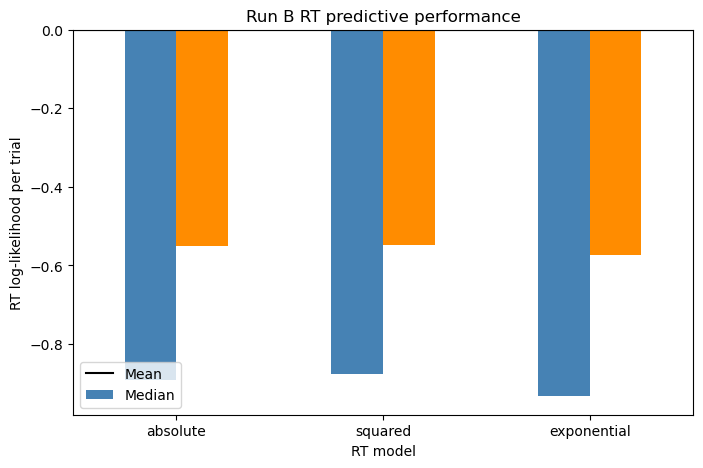

In [71]:
model_order = [
    "absolute",
    "squared",
    "exponential"
]

rt_score_summary = (
    full_model_results
    .groupby("model")[
        "test_rt_ll_per_trial"
    ]
    .agg(["mean", "median"])
    .loc[model_order]
)

rt_score_summary.plot(
    kind="bar",
    figsize=(8, 5),
    color=[
        "steelblue",
        "darkorange"
    ]
)

plt.axhline(
    0,
    color="black"
)

plt.xlabel("RT model")
plt.ylabel("RT log-likelihood per trial")
plt.title(
    "Run B RT predictive performance"
)

plt.xticks(rotation=0)
plt.legend(["Mean", "Median"])
plt.show()